In [1]:
from wrapper import BasicEnvironmentRGB, DomainRandomization
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation, TransformObservation
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from rltesting.torch_rl.buffers import ReplayBuffer
from rltesting.torch_rl.models import MLP, TargetNetwork
from fundamental_variable_discovery import Encoder, Decoder, DoubleAutoencoder
import torch.nn.functional as F
import numpy as np
import torch
import skdim
import time

to_numpy = lambda x: x.cpu().detach().numpy()
framestack = 2
latent_dim = 512
obs_shape = 64
data_steps = 5000
train_steps = 2000
l1_coeff = 0
env = gym.make('Acrobot-v1', render_mode="rgb_array")
# env = DomainRandomization(env, {"LINK_LENGTH_1": (0.5, 2.0), "LINK_LENGTH_2": (0.5, 2.0)})
env = BasicEnvironmentRGB(env, (obs_shape, obs_shape))
env = FrameStackObservation(env, stack_size=framestack)
env = TransformObservation(env, lambda obs: np.transpose(obs, (1, 2, 0, 3)), observation_space=gym.spaces.Box(0, 255, (framestack, 3, obs_shape, obs_shape), dtype=np.uint8))
env = TransformObservation(env, lambda obs: np.reshape(obs, (obs_shape, obs_shape, 3 * framestack)), observation_space=gym.spaces.Box(0, 255, (obs_shape, obs_shape, 3 * framestack), dtype=np.uint8))
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=data_steps)

In [2]:
samples = random_sample_single_env(env, num_steps=data_steps)
for i in range(data_steps):
    buffer.add_sample([samples[j][i] for j in range(len(samples))].copy())

0
1000


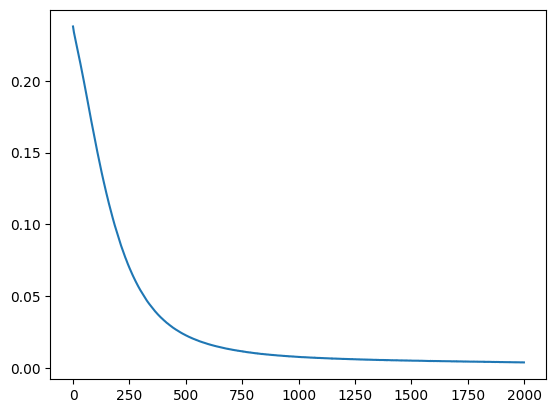

In [3]:
encoder = Encoder(framestack, latent_dim, obs_shape).cuda()
decoder = Decoder(encoder.conv_dim, framestack, latent_dim).cuda()
opt = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), 3e-4)
losses = []
for i in range(train_steps):
    if i % 1000 == 0:
        print(i)
    samples = buffer.sample(256)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    reconstruction = decoder(latent)
    loss = torch.nn.functional.mse_loss(reconstruction, obs)
    loss.backward()
    opt.step()
    opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())
plt.plot(losses)

In [ ]:
latent_ID = []
image_ID = []

for _ in range(20):
    samples = buffer.sample(2048)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    latent = encoder(obs)
    unique_latents = np.unique(latent.detach().cpu().numpy(), axis=0)
    unique_obs = np.unique(obs.detach().cpu().numpy(), axis=0).reshape(-1, 3 * framestack*obs_shape*obs_shape)

    latent_ID.append(skdim.id.MLE().fit(unique_latents).dimension_)
    image_ID.append(skdim.id.MLE().fit(unique_obs).dimension_)

print(f"Latent ID: {np.mean(latent_ID)} +- {np.std(latent_ID)}")
print(f"Image ID: {np.mean(image_ID)} +- {np.std(image_ID)}")

Latent ID: 3.7936434994228336 +- 0.03502619796893087
Image ID: 6.456778816639444 +- 0.07835899144301967


0
1000


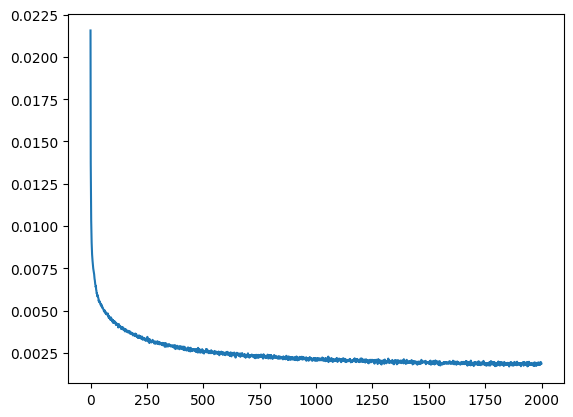

In [ ]:
intrinsic_dim = round(np.mean(latent_ID))
double_autoencoder = DoubleAutoencoder(encoder, decoder, latent_dim, intrinsic_dim).cuda()
int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)

losses = []
for i in range(train_steps):
    if i % 1000 == 0:
        print(i)
    samples = buffer.sample(256)
    obs = (torch.tensor(samples[0]).float().transpose(-3, -1) / 255).cuda()
    intrinsic = double_autoencoder.double_encode(obs)
    reconstruction = double_autoencoder.double_decode(intrinsic)
    loss = torch.nn.functional.mse_loss(reconstruction, obs)
    loss.backward()
    int_opt.step()
    int_opt.zero_grad()
    opt.step()
    opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())
plt.plot(losses)

In [6]:
torch.save(double_autoencoder, 'double_autoencoder_5d.pt')

In [7]:
# intrinsic_dim = 5
# double_autoencoder = torch.load('double_autoencoder_5d.pt', weights_only=False, map_location=torch.device('cuda'))
# int_opt = torch.optim.AdamW(double_autoencoder.parameters(), 3e-4)

In [6]:
num_actions = 3
q_network = MLP(intrinsic_dim, num_actions, skip_connections=False).cuda()
q_opt = torch.optim.Adam(q_network.parameters(), 3e-4)
dtypes = [np.uint8, np.float32, np.float32, np.uint8, np.float32]
buffer_shapes = [(obs_shape, obs_shape, 3 * framestack), (), (), (obs_shape, obs_shape, 3 * framestack), ()]
dqn_buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=100_000)
q_target = TargetNetwork(q_network, tau=5e-3).cuda()
eps = 1
eps_decay = 0.95
eps_min = 0.1
num_episodes = 500
train_after = 1000
gamma = 0.99

In [7]:
def dqn_loss(q_network, q_target, obs, action, reward, next_obs, done, q_opt):
    q_target.update()
    q_target = reward + gamma * q_target(next_obs).detach().gather(1, torch.argmax(q_network(next_obs).detach(), 1, keepdim=True)).squeeze() * (1 - done)
    q_values = q_network(obs).gather(1, action.unsqueeze(-1)).squeeze()
    q_loss = F.mse_loss(q_target, q_values)
    q_opt.zero_grad()
    q_loss.backward()
    q_opt.step()
    return q_loss

def model_losses(q_network, q_target, double_autoencoder, buffer, q_opt, double_ae_opt, batch_size=64):
    obs, action, reward, next_obs, done = buffer.sample(batch_size)
    obs = (torch.as_tensor(obs).float().transpose(-3, -1) / 255).cuda()
    action = torch.as_tensor(action).long().cuda()
    reward = torch.as_tensor(reward).float().cuda()
    next_obs = (torch.as_tensor(next_obs).float().transpose(-3, -1) / 255).cuda()
    done = torch.as_tensor(done).float().cuda()
    intrinsic = double_autoencoder.double_encode(obs)
    next_intrinsic = double_autoencoder.double_encode(next_obs).detach()
    q_loss = dqn_loss(q_network, q_target, intrinsic.detach(), action, reward, next_intrinsic, done, q_opt)
    
    reconstruction = double_autoencoder.double_decode(intrinsic)
    reconstruction_loss = F.mse_loss(reconstruction, obs)
    double_ae_opt.zero_grad()
    reconstruction_loss.backward()
    double_ae_opt.step()
    
    return to_numpy(q_loss.cpu()), to_numpy(reconstruction_loss.cpu())

In [8]:
ep_rews = []
q_losses = []
ae_losses = []
step = 0
ep_rew = 0
ep_rew_ema = None
for episode in range(num_episodes):
    if episode % 100 == 0:
        print(episode, ep_rew)
    obs, _ = env.reset()
    done = False
    ep_rew = 0
    q_loss_ = []
    ae_loss_ = []
    while not done:
        step += 1
        if step > train_after:
            obs_tensor = (torch.tensor(obs).float().transpose(-3, -1) / 255).cuda()
            if np.random.rand() < eps:
                action = np.random.randint(num_actions)
            else:
                intrinsic = double_autoencoder.double_encode(obs_tensor.unsqueeze(0))
                action = to_numpy(q_network(intrinsic).argmax())
            start_time = time.time()
            q_loss, ae_loss = model_losses(q_network, q_target, double_autoencoder, dqn_buffer, q_opt, int_opt)
            print(time.time() - start_time)
            q_loss_.append(q_loss)
            ae_loss_.append(ae_loss)
        else:
            action = env.action_space.sample()
        next_obs, reward, term, trunc, _ = env.step(action)
        done = term or trunc
        dqn_buffer.add_sample([obs, action, reward, next_obs, done])
        ep_rew += reward
        obs = next_obs
    ep_rews.append(ep_rew)
    q_losses.append(np.mean(q_loss_))
    ae_losses.append(np.mean(ae_loss_))
    eps = max(eps_min, eps * eps_decay)

0 0
0.05799698829650879
0.028084516525268555
0.0314178466796875
0.026384353637695312
0.03187298774719238
0.012117624282836914
0.009807348251342773
0.009573698043823242
0.011222600936889648
0.011054277420043945
0.009892940521240234
0.01111912727355957
0.009203672409057617
0.00906991958618164
0.009453773498535156
0.00982809066772461
0.009615421295166016
0.01002192497253418
0.008968591690063477
0.009988069534301758
0.009598731994628906
0.009849309921264648
0.010220050811767578
0.009904623031616211
0.010137319564819336
0.009932994842529297
0.009711980819702148
0.009950876235961914
0.010195732116699219
0.009129524230957031
0.009612321853637695
0.010260581970214844
0.010790109634399414
0.009435892105102539
0.009557247161865234
0.010539054870605469
0.009293079376220703
0.009298324584960938
0.009496927261352539
0.011003255844116211
0.009910821914672852
0.01035618782043457
0.011244535446166992
0.009578466415405273
0.009667634963989258
0.010553598403930664
0.010384321212768555
0.0090725421905517

KeyboardInterrupt: 

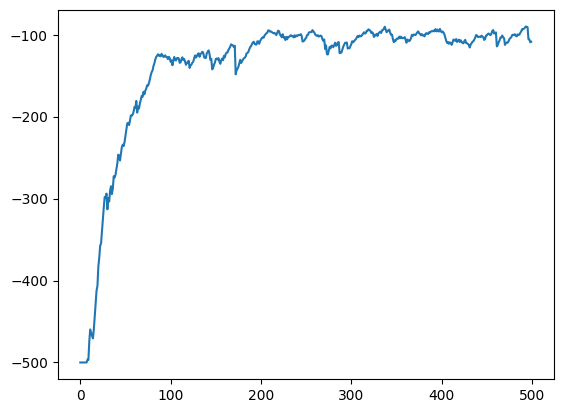

In [38]:
smoothing = 0.9
ep_rew_ema = None
smoothed_rewards = []
for ep_rew in ep_rews:
    if ep_rew_ema is None:
        ep_rew_ema = ep_rew
    else:
        ep_rew_ema = smoothing * ep_rew_ema + (1 - smoothing) * ep_rew
    smoothed_rewards.append(ep_rew_ema)
plt.plot(smoothed_rewards)
plt.savefig("smoothed_ep_rew.png")
np.save("smoothed_rewards.npy", np.asarray(smoothed_rewards))

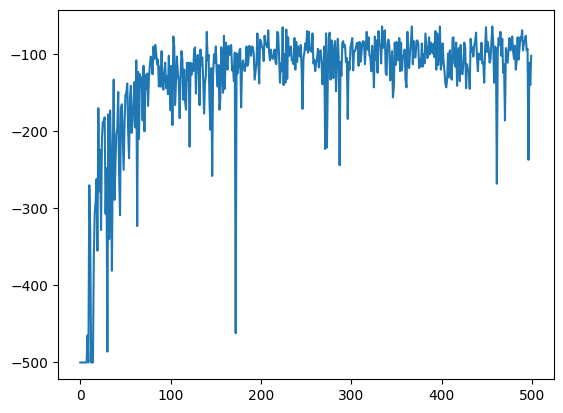

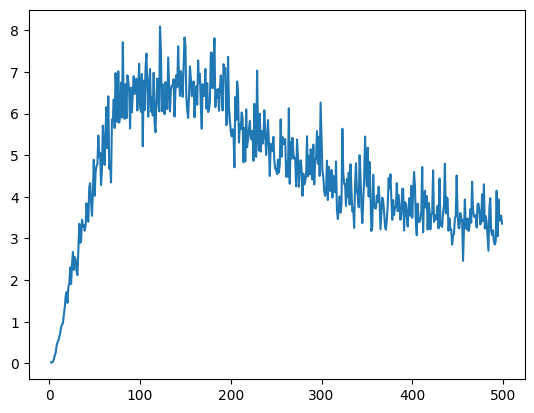

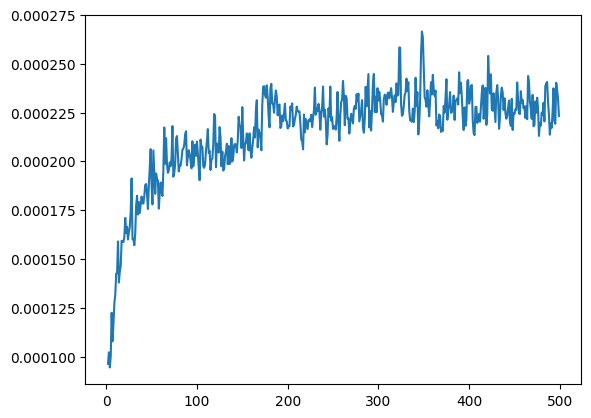

In [39]:
plt.plot(ep_rews)
plt.savefig("ep_rew.png")
plt.show()
plt.plot(q_losses)
plt.show()
plt.plot(ae_losses)
plt.show()